# Defect detection pipeline

Does super-resolving a low-resolution capture improve automated defect detection? Every method reconstructs the same LR test split at the HR frame size, and the reconstructions are classified with the fine-tuned VGG16.

Thirteen rows are compared: the LR baseline, the HR ceiling, the three learned models (SRCNN, EDSR, ESRGAN), the four interpolations and the four advanced classic algorithms. The eleven reconstructions all produce RGB images at 478x478, which is the regime the HR classifier was trained on.

The two reference rows bracket the comparison and neither is reconstructed. The LR baseline is the only row scored with the LR-trained classifier, at its native resolution, so comparing an SR row against it isolates the effect of the reconstruction rather than a change of classifier input size. The HR row is the original frame scored by the same classifier that scores every reconstruction, which is what turns an absolute accuracy into a readable one: a method at 91 % means something different if HR reaches 93 % than if it reaches 99 %.

Requires `4_srcnn`, `5_edsr`, `6_esrgan` and `8_vgg16` to have been run.

In [1]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from srlib.constants import CLASS_LABELS_PATH, HR_ROOT, LR_ROOT
from srlib.dataset.loading import load_defect_detection_pipeline_dataset
from srlib.defect_detection.pipeline import DefectDetectionPipeline
from srlib.model_registry import print_available_runs

c:\Users\bgmanuel\anaconda3\envs\py310\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\bgmanuel\anaconda3\envs\py310\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.10.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.

## Load the test split

The same split the classifier was trained against, so the test images were never seen during training.

In [2]:
(
    X_LR_train, X_HR_train, y_train,
    X_LR_val, X_HR_val, y_val,
    X_LR_test, X_HR_test, y_test,
) = load_defect_detection_pipeline_dataset(HR_ROOT, LR_ROOT, CLASS_LABELS_PATH)

print(f"LR splits -> train: {X_LR_train.shape}, val: {X_LR_val.shape}, test: {X_LR_test.shape}")
print(f"HR splits -> train: {X_HR_train.shape}, val: {X_HR_val.shape}, test: {X_HR_test.shape}")
print(f"y splits  -> train: {y_train.shape}, val: {y_val.shape}, test: {y_test.shape}")


 Detection pipeline dataset | full frames
  images    798 indexed -> 798 kept -> 574 train / 64 val / 160 test


  frames    LR 239x239 | HR 478x478
  test      160 images, the split the pipeline scores
  done in 6.7s

LR splits -> train: (574, 239, 239, 3), val: (64, 239, 239, 3), test: (160, 239, 239, 3)
HR splits -> train: (574, 478, 478, 3), val: (64, 478, 478, 3), test: (160, 478, 478, 3)
y splits  -> train: (574,), val: (64,), test: (160,)


## Run the pipeline

Leave a run as `None` to take the most recent checkpoint of that model, or pin a timestamp to reproduce an older comparison.

In [3]:
print_available_runs()

SRCNN: 1 run(s)
  - 20260914_180459 (latest)
EDSR: 1 run(s)
  - 20260914_204828 (latest)
ESRGAN: 1 run(s)
  - 20260915_175433 (latest)
VGG16: 1 run(s)
  - 20260914_235902 (latest)


In [4]:
pipeline = DefectDetectionPipeline(
    X_LR_test=X_LR_test,
    X_HR_test=X_HR_test,
    y_test=y_test,
    srcnn_run=None,
    edsr_run=None,
    esrgan_run=None,
    vgg16_run=None,
)

sr_images, labels, confidences = pipeline.run()

Resolved runs
  SRCNN   20260914_180459
  EDSR    20260914_204828
  ESRGAN  20260915_175433
  VGG16   20260914_235902
  HR frame size: 478 x 478
Loading models
Loaded pretrained model from c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\SRCNN\SRCNN_20260914_180459\SRCNN_20260914_180459.h5
Loaded pretrained model from c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\EDSR\EDSR_20260914_204828\EDSR_x2_20260914_204828.h5
- Generator loaded from: c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\ESRGAN\ESRGAN_20260915_175433\ESRGAN_generator_x2_20260915_175433.h5
- Discriminator loaded from: c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\ESRGAN\ESRGAN_20260915_175433\ESRGAN_discriminator_x2_202

SRCNN inference: 100%|██████████| 160/160 [00:16<00:00,  9.67it/s]


  SRCNN                  16.54s  (160 images)


EDSR inference: 100%|██████████| 160/160 [00:13<00:00, 12.05it/s]


  EDSR                   13.28s  (160 images)


...

  Non-Local Means      accuracy=0.9750


VGG16-HR on Edge-guided: 100%|██████████| 160/160 [00:13<00:00, 11.71it/s]


  Edge-guided          accuracy=0.6937


VGG16-HR on Freq-extrapolation: 100%|██████████| 160/160 [00:13<00:00, 11.59it/s]

  Freq-extrapolation   accuracy=0.9500
Predictions done in 180.13s

Pipeline finished in 303.30s


## Confusion matrices

One matrix per method, in evaluation order.

(<Figure size 1800x2500 with 15 Axes>,
 array([[<Axes: title={'center': 'LR Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>,
         <Axes: title={'center': 'HR Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>,
         <Axes: title={'center': 'SRCNN Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>],
        [<Axes: title={'center': 'EDSR Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>,
         <Axes: title={'center': 'ESRGAN Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>,
         <Axes: title={'center': 'Bilinear Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>],
        [<Axes: title={'center': 'Bicubic Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>,
         <Axes: title={'center': 'Area Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>,
         <Axes: title={'center': 'Lanczos Confusion Matrix'}, xlabel='Predicted label', ylabel='T

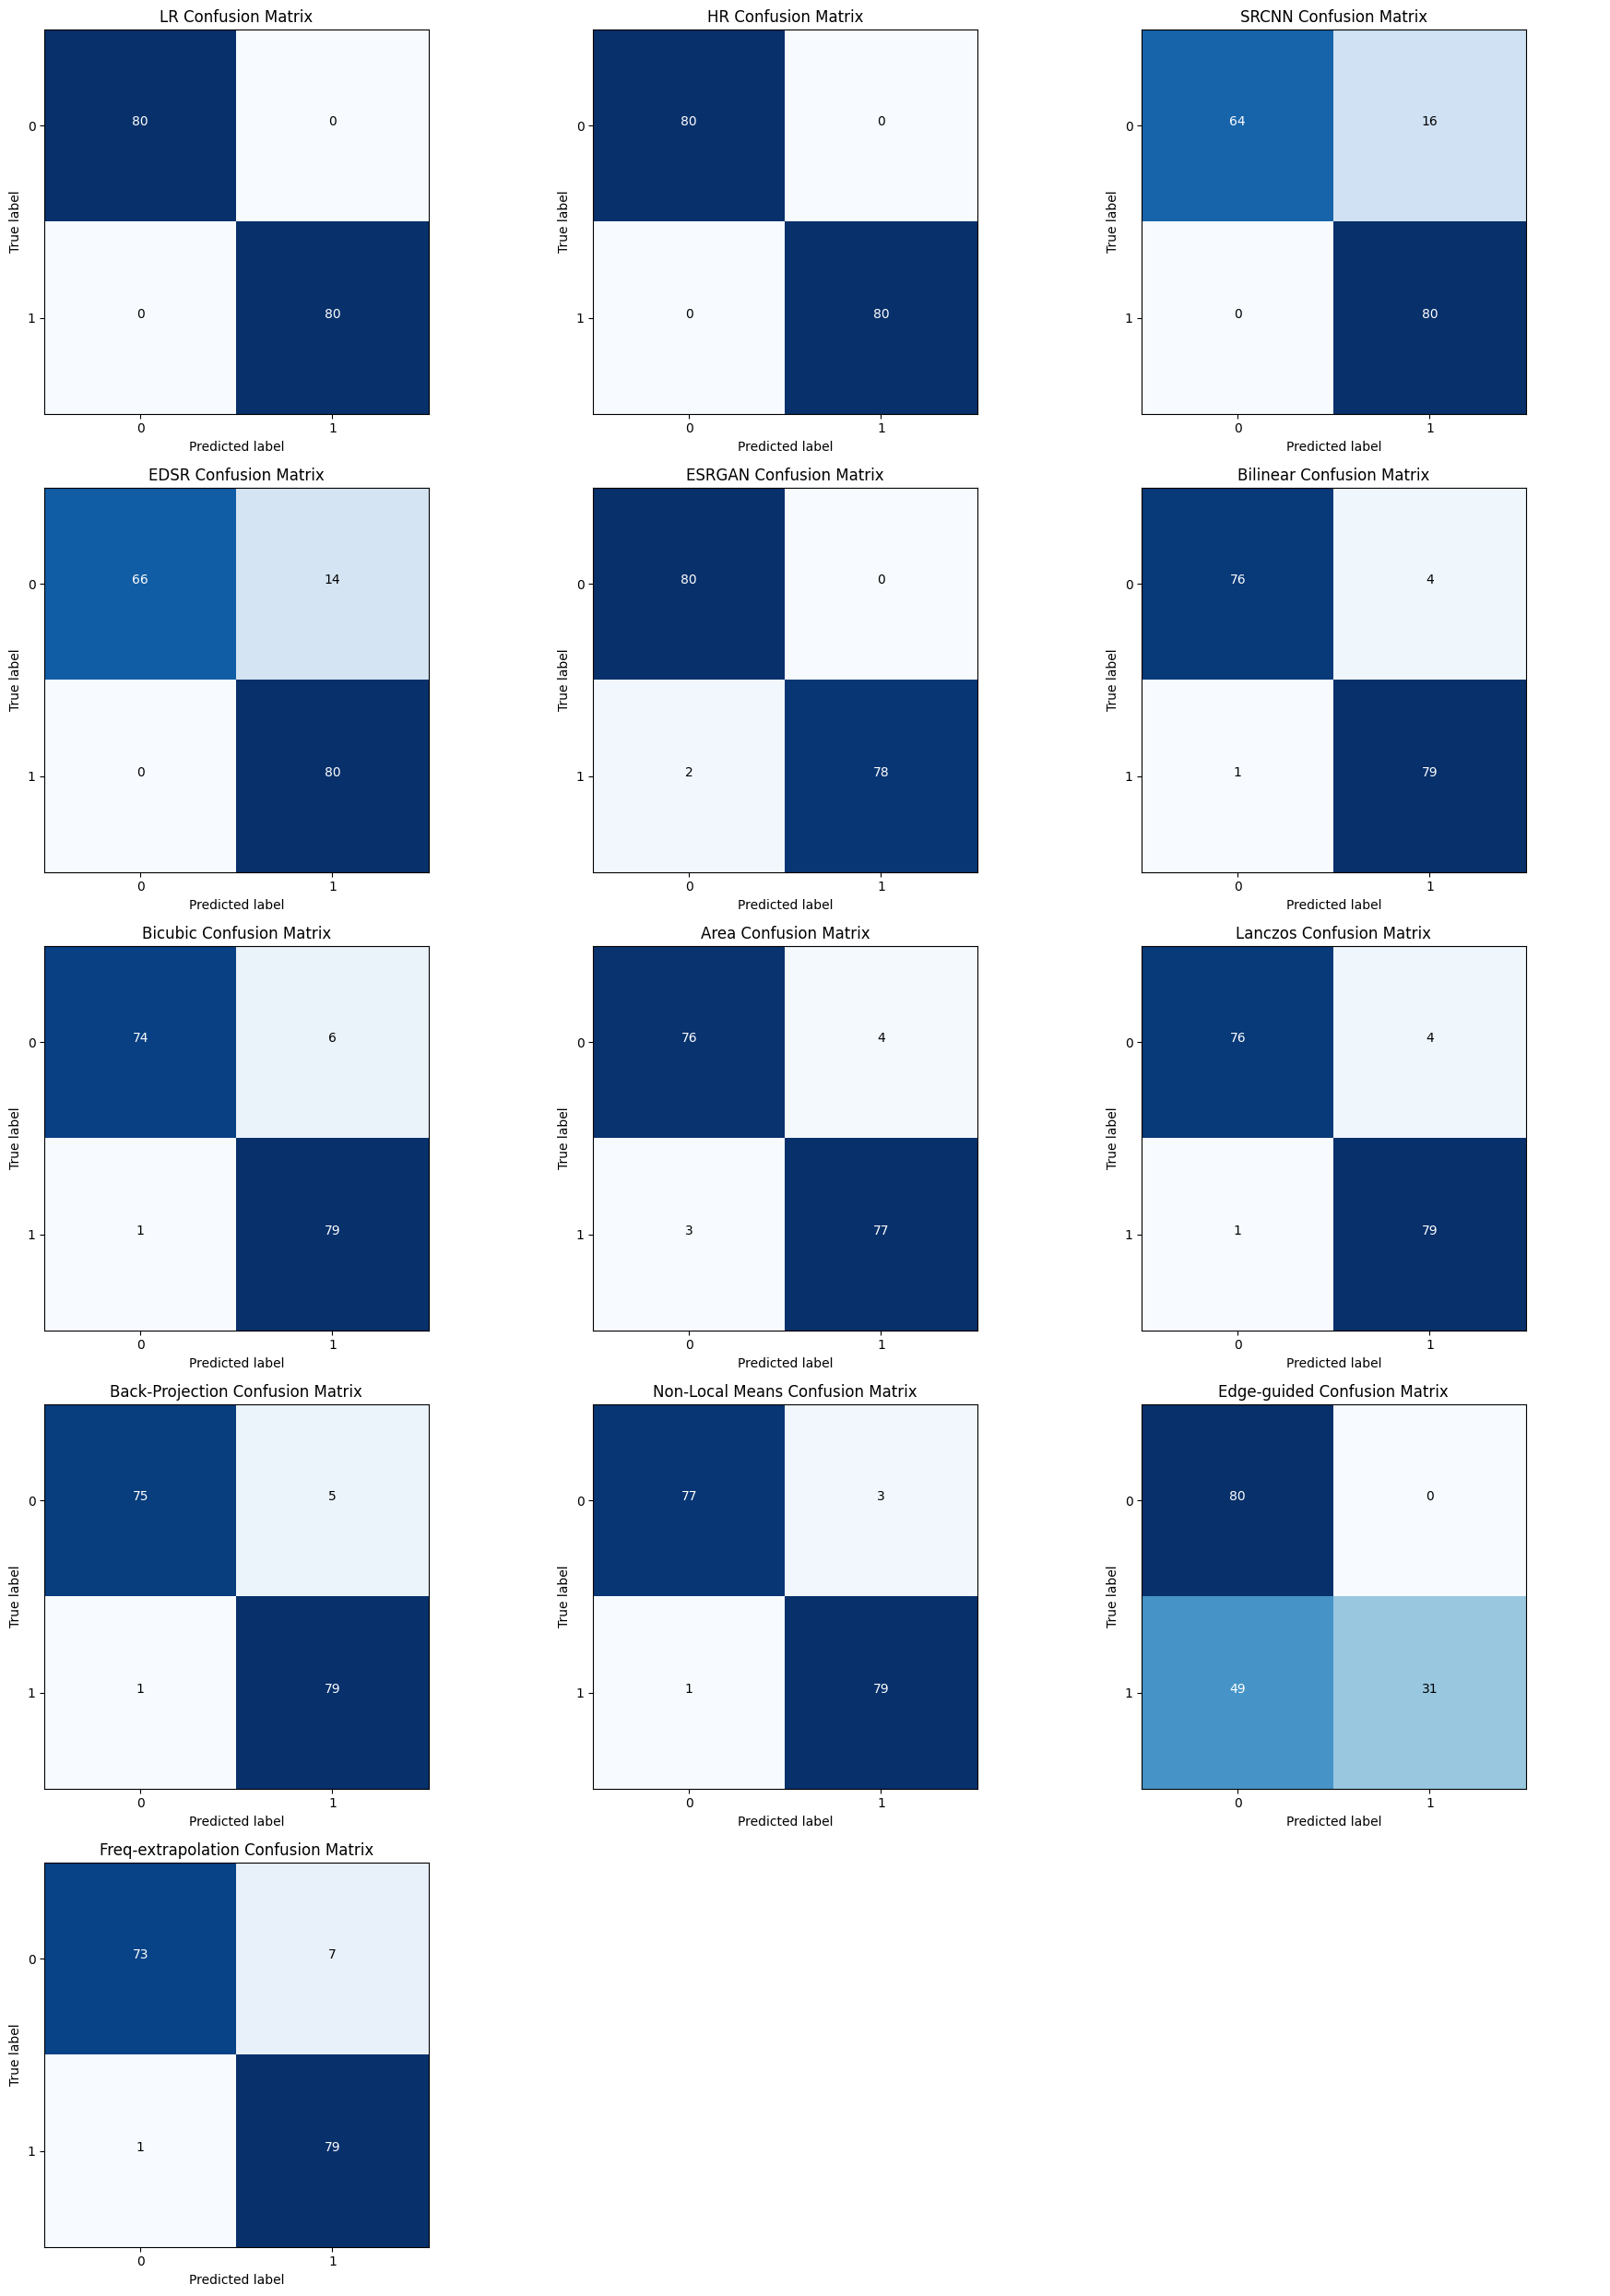

In [5]:
pipeline.plot_confusion_matrices()

## Classification report

Accuracy, macro recall and both F1 aggregates, plus the same scores resolved per class. The dataset is imbalanced, so macro F1 is the figure to read rather than accuracy.

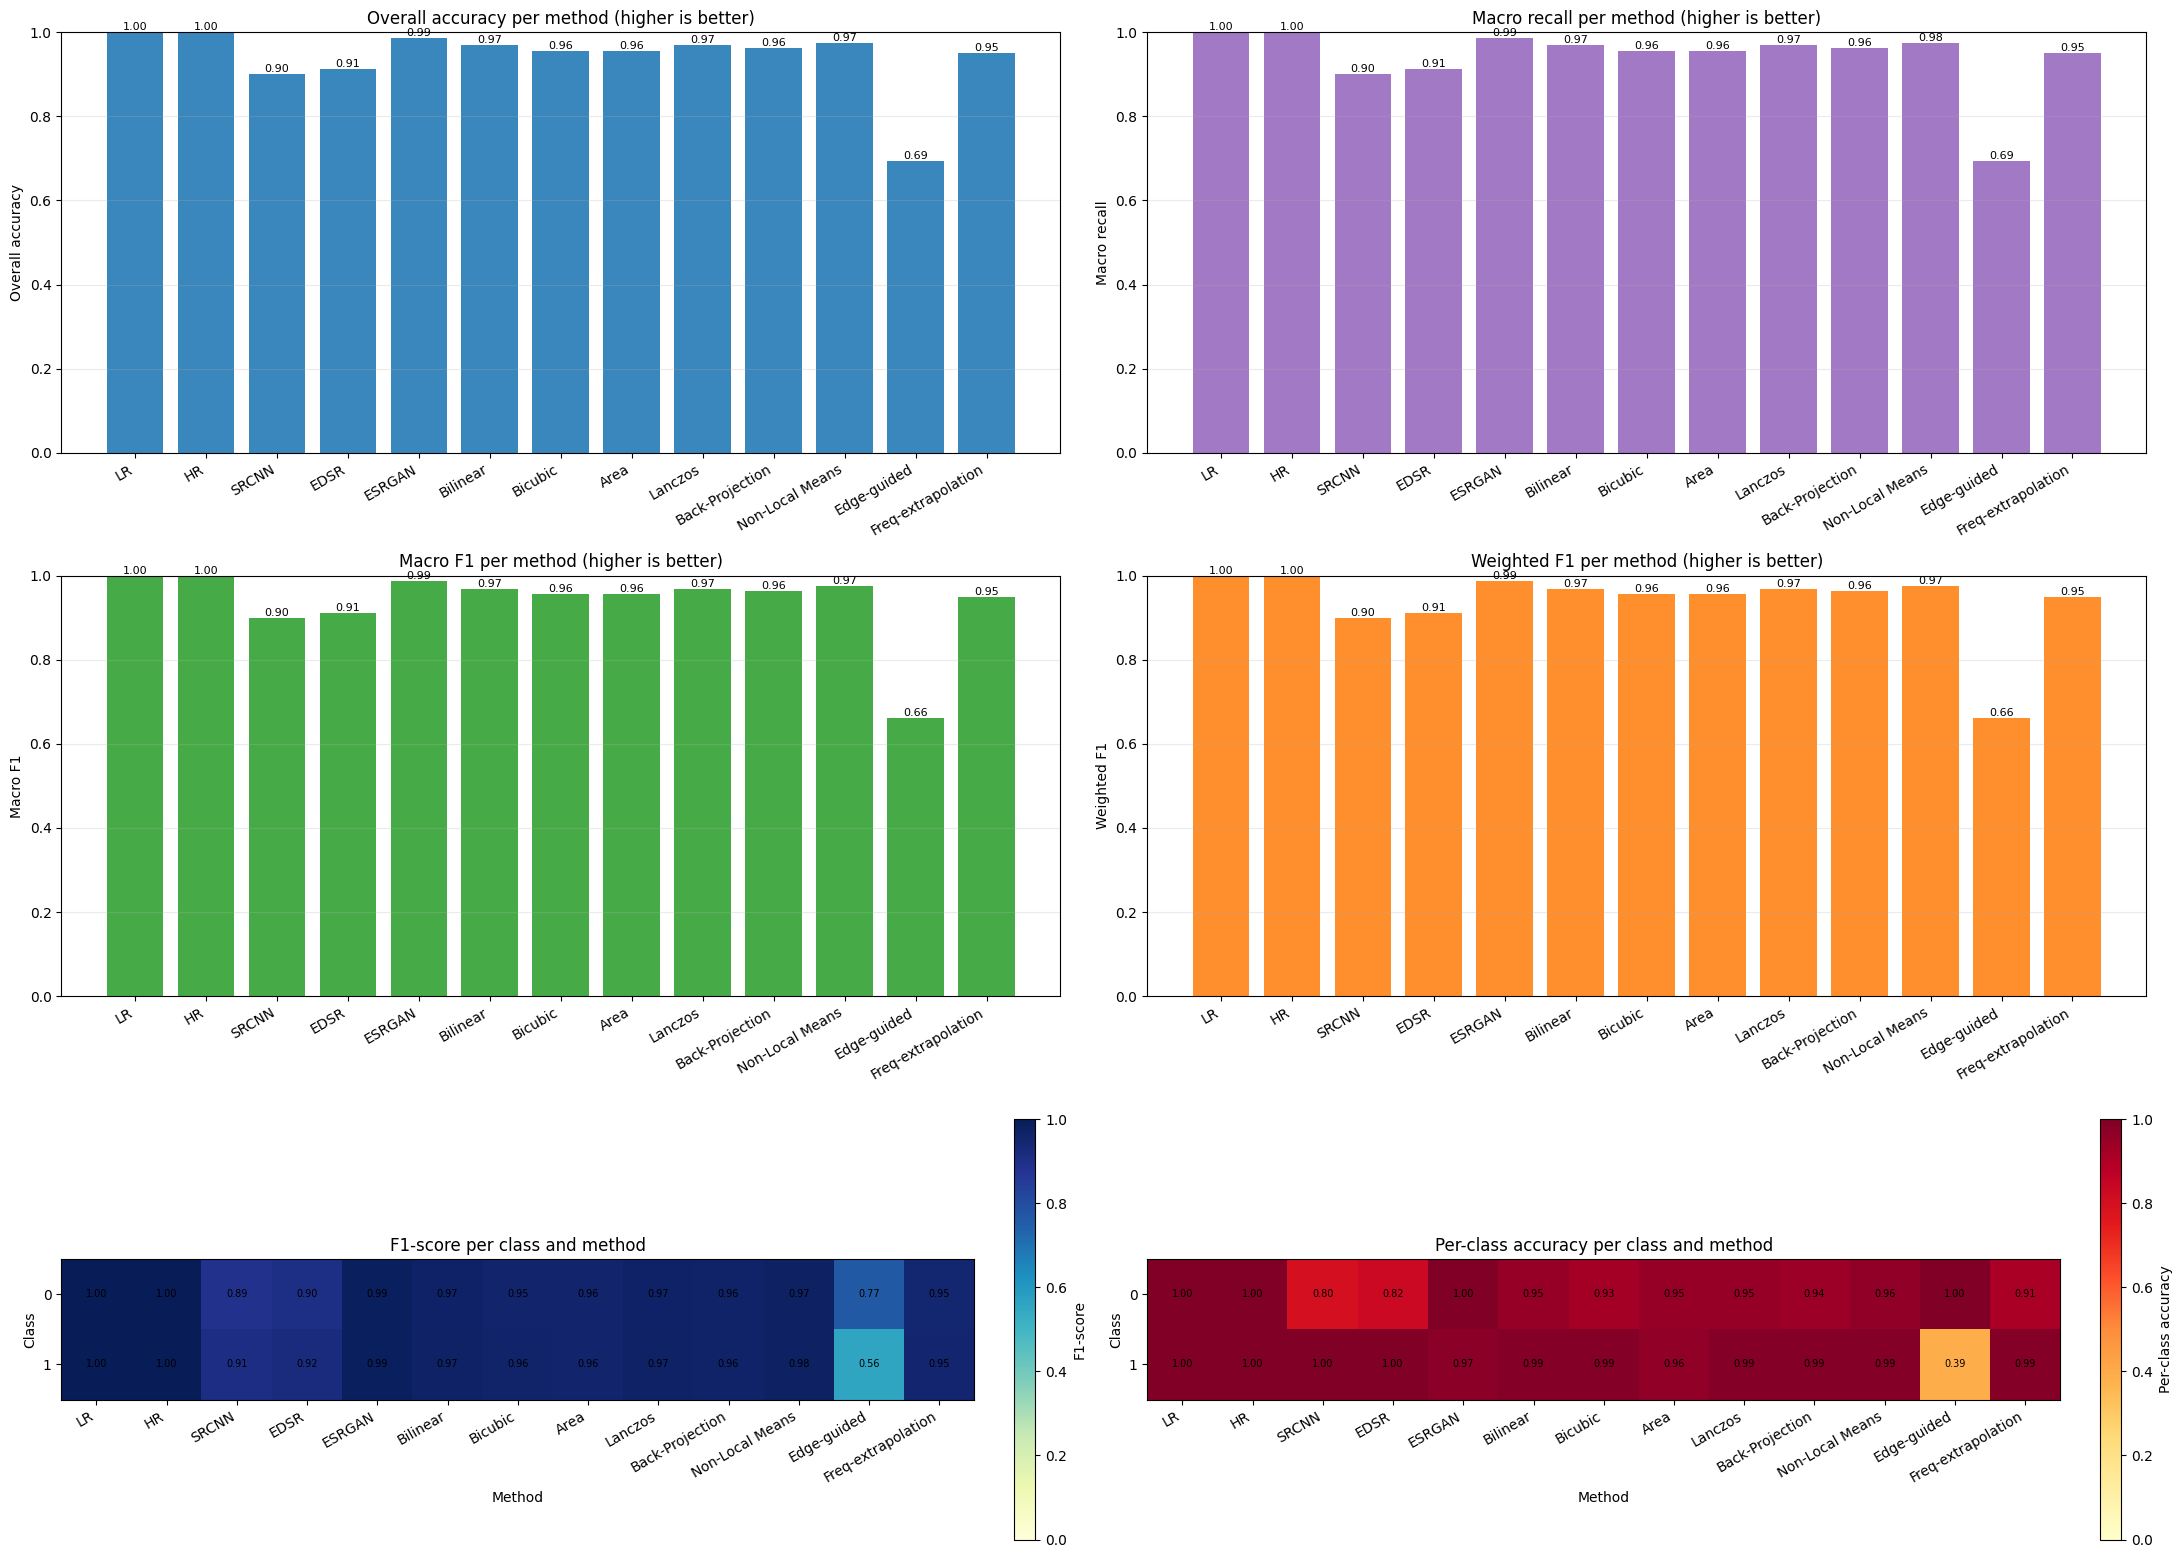

In [6]:
fig, axes, report_metrics = pipeline.plot_classification_reports()

## Confidence

Global mean confidence, the same split into correct and wrong predictions, and the error rate. The three together are what tell whether a method is confidently wrong.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


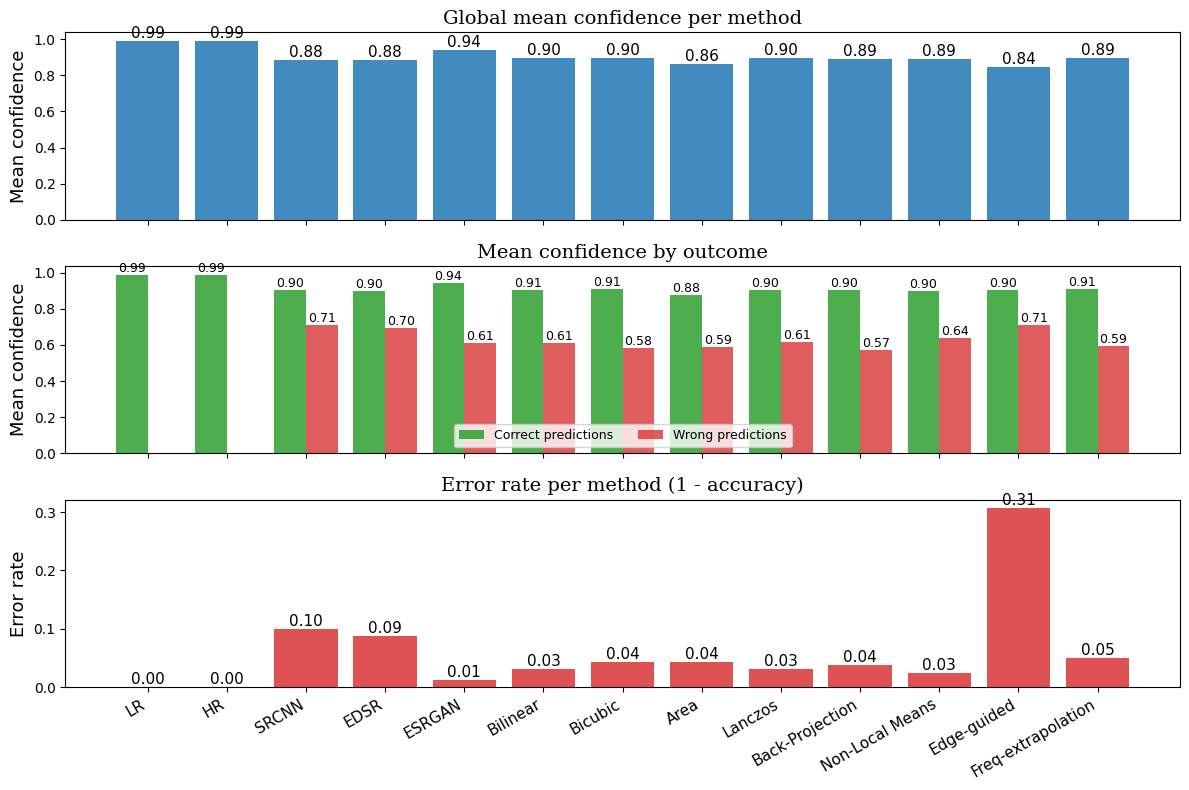

In [7]:
fig, axes, confidence_metrics = pipeline.plot_confidence()

## Qualitative comparison

Every reconstruction of a single test image with the prediction it produced. Change `index` to inspect another sample.

(<Figure size 750x1250 with 15 Axes>,
 array([[<Axes: title={'center': 'LR (Pred: 1, Conf: 1.00)'}>,
         <Axes: title={'center': 'HR (Pred: 1, Conf: 1.00)'}>,
         <Axes: title={'center': 'SRCNN (Pred: 1, Conf: 1.00)'}>],
        [<Axes: title={'center': 'EDSR (Pred: 1, Conf: 1.00)'}>,
         <Axes: title={'center': 'ESRGAN (Pred: 1, Conf: 1.00)'}>,
         <Axes: title={'center': 'Bilinear (Pred: 1, Conf: 1.00)'}>],
        [<Axes: title={'center': 'Bicubic (Pred: 1, Conf: 1.00)'}>,
         <Axes: title={'center': 'Area (Pred: 1, Conf: 0.98)'}>,
         <Axes: title={'center': 'Lanczos (Pred: 1, Conf: 1.00)'}>],
        [<Axes: title={'center': 'IBP (Pred: 1, Conf: 1.00)'}>,
         <Axes: title={'center': 'NLM (Pred: 1, Conf: 1.00)'}>,
         <Axes: title={'center': 'EGI (Pred: 1, Conf: 1.00)'}>],
        [<Axes: title={'center': 'FDE (Pred: 1, Conf: 1.00)'}>, <Axes: >,
         <Axes: >]], dtype=object))

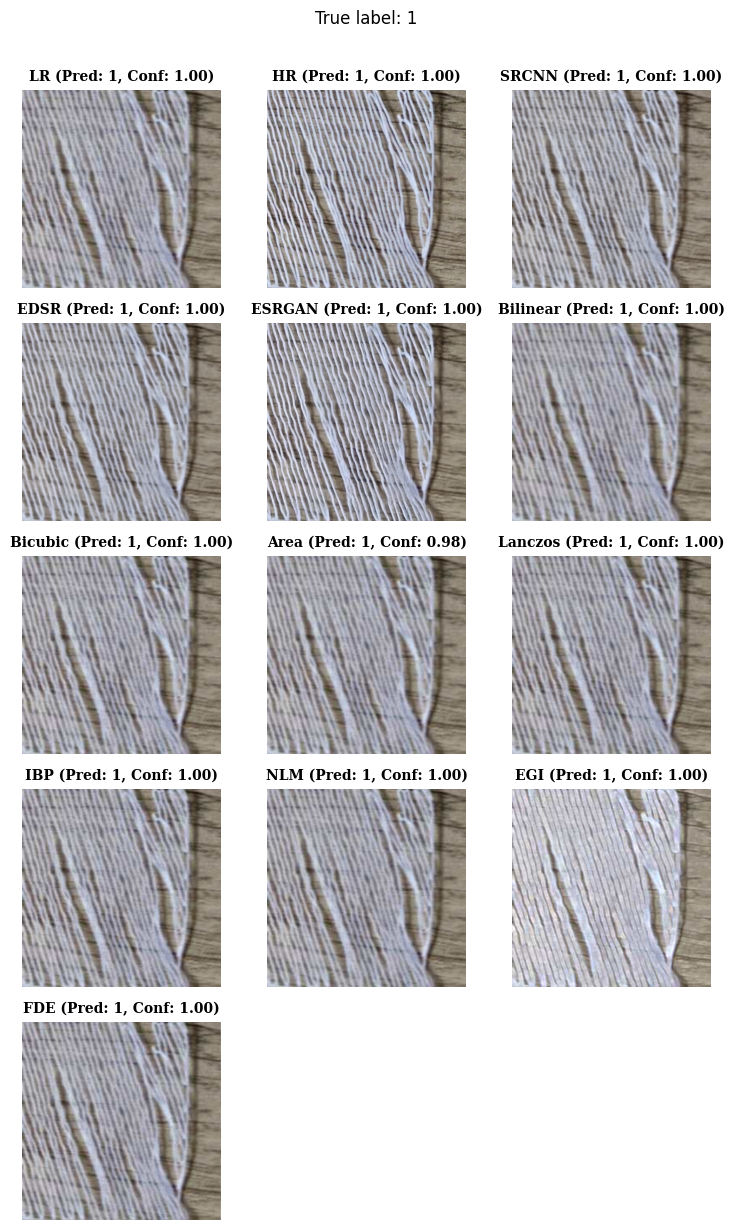

In [8]:
pipeline.plot_sample_predictions(index=9)

Time and memory of the learned models are reported in notebook 7, measured over training and over the test evaluation. Reconstructing a frame patch by patch is a cost of this pipeline, not of the models, so it is not attributed to them.